In [1]:
%matplotlib inline
import os, sys, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("mediapipe:", mp.__version__)

# --- Resolve image path (same idea as before) ---
BASE = r"C:\Users\islam\SportsPose\data\data\photos\IMG_7969"
SEARCH_EXTS = [".jpg", ".jpeg", ".png", ".heic", ".JPG", ".JPEG", ".PNG", ".HEIC"]
candidates = [p for ext in SEARCH_EXTS for p in glob.glob(BASE + ext)]
IMG_PATH = candidates[0] if candidates else BASE

OUT_DIR = r"C:\Users\islam\SportsPose\results"
os.makedirs(OUT_DIR, exist_ok=True)

print("Resolved IMG_PATH:", IMG_PATH)


Python: 3.9.24
numpy: 1.26.4
opencv: 4.9.0
mediapipe: 0.10.21
Resolved IMG_PATH: C:\Users\islam\SportsPose\data\data\photos\IMG_7969.png


In [2]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

img_bgr = cv2.imread(IMG_PATH)
assert img_bgr is not None, f"Could not read image: {IMG_PATH}"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

with mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5
) as pose:

    results = pose.process(img_rgb)

# Check detection
if not results.pose_landmarks:
    raise RuntimeError("No pose detected by MediaPipe Pose.")

# Draw landmarks on a copy
overlay = img_rgb.copy()
mp_drawing.draw_landmarks(
    overlay,
    results.pose_landmarks,
    mp_pose.POSE_CONNECTIONS,
    landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style()
)

plt.figure(figsize=(8,6))
plt.imshow(overlay)
plt.title("MediaPipe Pose Landmarks")
plt.axis("off")
plt.show()

out_img_path = os.path.join(OUT_DIR, "mediapipe_pose_overlay.jpg")
cv2.imwrite(out_img_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Saved overlay to:", out_img_path)


<Figure size 800x600 with 1 Axes>

Saved overlay to: C:\Users\islam\SportsPose\results\mediapipe_pose_overlay.jpg


In [7]:
# MediaPipe pose has 33 landmarks
lm2d = results.pose_landmarks.landmark
assert len(lm2d) == 33, len(lm2d)

# 2D in pixels
coords2d = []
for lm in lm2d:
    x_px = lm.x * w
    y_px = lm.y * h
    coords2d.append([x_px, y_px])
coords2d = np.array(coords2d, dtype=float)  # (33, 2)

# 3D world coordinates (if available)
if not results.pose_world_landmarks:
    raise RuntimeError("No world landmarks from MediaPipe (pose_world_landmarks is None).")

lm3d = results.pose_world_landmarks.landmark
assert len(lm3d) == 33

coords3d = []
for lm in lm3d:
    coords3d.append([lm.x, lm.y, lm.z])   # meters in a canonical world space
coords3d = np.array(coords3d, dtype=float)  # (33, 3)

# For consistency with your old pipeline: shape (n_person, n_joints, dim)
poses2d = coords2d[None, ...]  # (1, 33, 2)
poses3d = coords3d[None, ...]  # (1, 33, 3)

print("poses2d shape:", poses2d.shape)
print("poses3d shape:", poses3d.shape)


poses2d shape: (1, 33, 2)
poses3d shape: (1, 33, 3)


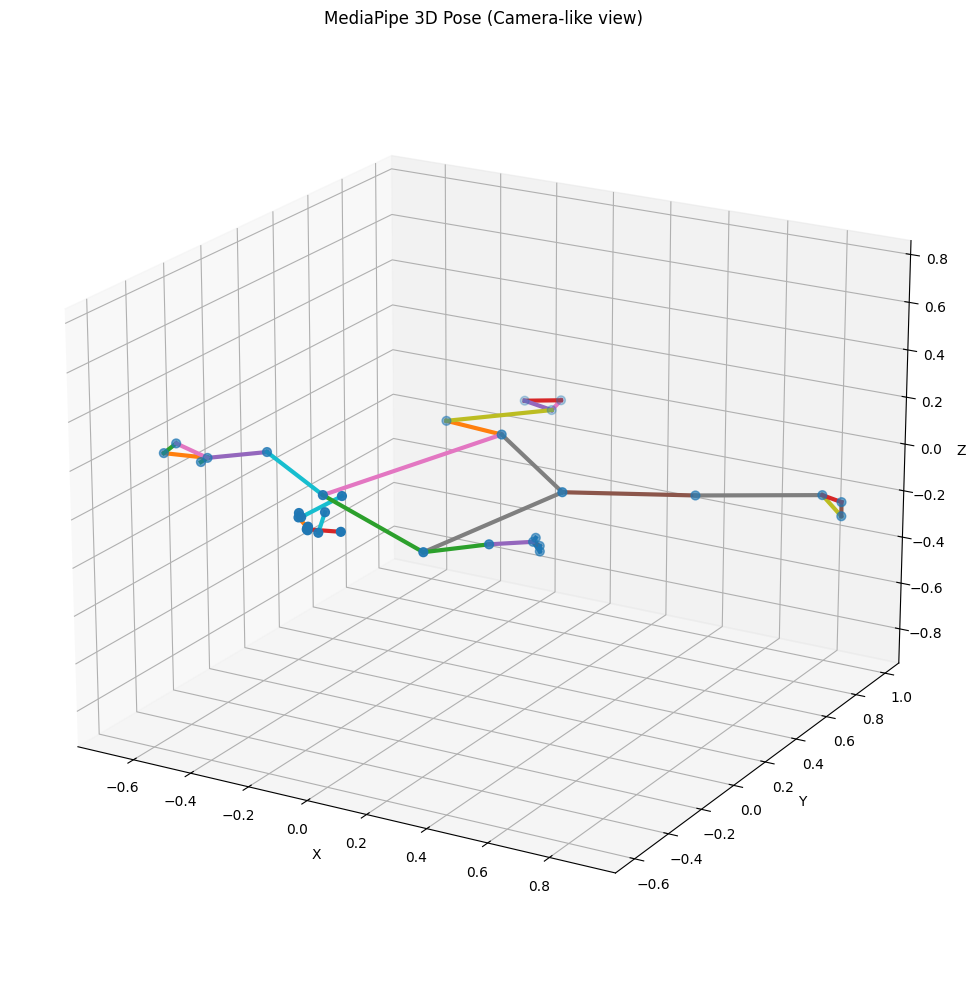

Saved corrected 3D view: C:\Users\islam\SportsPose\results\mediapipe_3D_pose_fixed.jpg


In [10]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

lm3d = results.pose_world_landmarks.landmark

# Extract raw world coords
X = np.array([lm.x for lm in lm3d])
Y = np.array([lm.y for lm in lm3d])
Z = np.array([lm.z for lm in lm3d])

# ----- FIX THE ORIENTATION -----
# 1. Flip X so it matches image view
X = -X

# 2. Flip Z so depth goes positive inward
Z = -Z

# 3. Normalize scale so body is not tiny
scale = np.max(np.abs([X, Y, Z]))
X = X / scale
Y = Y / scale
Z = Z / scale

# 4. Optional: shift to center
X = X - np.mean(X)
Y = Y - np.mean(Y)
Z = Z - np.mean(Z)

# ----- Plot -----
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

# Scatter points
ax.scatter(X, Y, Z, s=40)

# Draw MediaPipe connections
for i,j in mp_pose.POSE_CONNECTIONS:
    ax.plot([X[i], X[j]], [Y[i], Y[j]], [Z[i], Z[j]], linewidth=3)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("MediaPipe 3D Pose (Camera-like view)")

# Make the aspect ratio equal
max_range = np.array([X.max()-X.min(),
                      Y.max()-Y.min(),
                      Z.max()-Z.min()]).max() / 2.0

mid_x = (X.max()+X.min()) * 0.5
mid_y = (Y.max()+Y.min()) * 0.5
mid_z = (Z.max()+Z.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

# Save
out_path = os.path.join(OUT_DIR, "mediapipe_3D_pose_fixed.jpg")
fig.savefig(out_path, dpi=300)
print("Saved corrected 3D view:", out_path)


In [8]:
import pandas as pd

# Output folder for tables
OUTPUT_DIR = os.path.join(OUT_DIR, "outputMEDIAPIPE")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MediaPipe 33 joint names (official order)
JOINT_NAMES_33 = [
    "nose",                 # 0
    "left_eye_inner",       # 1
    "left_eye",             # 2
    "left_eye_outer",       # 3
    "right_eye_inner",      # 4
    "right_eye",            # 5
    "right_eye_outer",      # 6
    "left_ear",             # 7
    "right_ear",            # 8
    "mouth_left",           # 9
    "mouth_right",          # 10
    "left_shoulder",        # 11
    "right_shoulder",       # 12
    "left_elbow",           # 13
    "right_elbow",          # 14
    "left_wrist",           # 15
    "right_wrist",          # 16
    "left_pinky",           # 17
    "right_pinky",          # 18
    "left_index",           # 19
    "right_index",          # 20
    "left_thumb",           # 21
    "right_thumb",          # 22
    "left_hip",             # 23
    "right_hip",            # 24
    "left_knee",            # 25
    "right_knee",           # 26
    "left_ankle",           # 27
    "right_ankle",          # 28
    "left_heel",            # 29
    "right_heel",           # 30
    "left_foot_index",      # 31
    "right_foot_index"      # 32
]

# ---- 2D sheet ----
rows_2d = []
for j in range(33):
    x_px, y_px = poses2d[0, j]
    rows_2d.append({
        "joint_index": j,
        "joint_name": JOINT_NAMES_33[j],
        "x_px": float(x_px),
        "y_px": float(y_px)
    })
df2d = pd.DataFrame(rows_2d)

# ---- 3D sheet ----
rows_3d = []
for j in range(33):
    X, Y, Z = poses3d[0, j]
    rows_3d.append({
        "joint_index": j,
        "joint_name": JOINT_NAMES_33[j],
        "X_world": float(X),
        "Y_world": float(Y),
        "Z_world": float(Z)
    })
df3d = pd.DataFrame(rows_3d)

excel_path = os.path.join(OUTPUT_DIR, "mediapipe_coordinates_2D_3D.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    df2d.to_excel(writer, sheet_name="2D_pixels", index=False)
    df3d.to_excel(writer, sheet_name="3D_world", index=False)

print("Saved Excel with MediaPipe coordinates to:", excel_path)
df2d.head()



Saved Excel with MediaPipe coordinates to: C:\Users\islam\SportsPose\results\output\mediapipe_coordinates_2D_3D.xlsx


,joint_index,joint_name,x_px,y_px
0,0,nose,493.668686,535.216553
1,1,left_eye_inner,488.551300,519.450256
2,2,left_eye,486.597839,518.823120
3,3,left_eye_outer,484.604324,518.317139
4,4,right_eye_inner,491.832916,520.709473


In [11]:
import numpy as np
import pandas as pd
import os

assert 'poses2d' in globals() and 'poses3d' in globals(), "Run the MediaPipe coord cells first."
assert 'OUT_DIR' in globals(), "OUT_DIR must be defined."
assert 'mp_pose' in globals(), "mp_pose must be imported (mediapipe.solutions.pose)."

# Output folder
OUTPUT_DIR = os.path.join(OUT_DIR, "outputMEDIAPIPE")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MediaPipe 33 joint names (same as before)
JOINT_NAMES_33 = [
    "nose",                 # 0
    "left_eye_inner",       # 1
    "left_eye",             # 2
    "left_eye_outer",       # 3
    "right_eye_inner",      # 4
    "right_eye",            # 5
    "right_eye_outer",      # 6
    "left_ear",             # 7
    "right_ear",            # 8
    "mouth_left",           # 9
    "mouth_right",          # 10
    "left_shoulder",        # 11
    "right_shoulder",       # 12
    "left_elbow",           # 13
    "right_elbow",          # 14
    "left_wrist",           # 15
    "right_wrist",          # 16
    "left_pinky",           # 17
    "right_pinky",          # 18
    "left_index",           # 19
    "right_index",          # 20
    "left_thumb",           # 21
    "right_thumb",          # 22
    "left_hip",             # 23
    "right_hip",            # 24
    "left_knee",            # 25
    "right_knee",           # 26
    "left_ankle",           # 27
    "right_ankle",          # 28
    "left_heel",            # 29
    "right_heel",           # 30
    "left_foot_index",      # 31
    "right_foot_index"      # 32
]

def angle_3d(A, B, C):
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    C = np.asarray(C, float)
    BA = A - B
    BC = C - B
    dot = np.dot(BA, BC)
    norm = np.linalg.norm(BA) * np.linalg.norm(BC)
    if norm < 1e-8:
        return np.nan
    cos_t = np.clip(dot / norm, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_t)))

def angle_2d(A, B, C):
    A = np.asarray(A[:2], float)
    B = np.asarray(B[:2], float)
    C = np.asarray(C[:2], float)
    BA = A - B
    BC = C - B
    dot = np.dot(BA, BC)
    norm = np.linalg.norm(BA) * np.linalg.norm(BC)
    if norm < 1e-8:
        return np.nan
    cos_t = np.clip(dot / norm, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_t)))

# Build neighbor list from MediaPipe connections
neighbors = {i: set() for i in range(33)}
for i, j in mp_pose.POSE_CONNECTIONS:
    neighbors[i].add(j)
    neighbors[j].add(i)

p2d = poses2d[0]  # (33,2)
p3d = poses3d[0]  # (33,3)

rows = []

for center in range(33):
    nbrs = sorted(list(neighbors[center]))
    if len(nbrs) < 2:
        continue  # need at least 2 neighbors to form an angle

    # all unordered neighbor pairs (A,B,C where center is B)
    for i_idx in range(len(nbrs)):
        for j_idx in range(i_idx + 1, len(nbrs)):
            iA = nbrs[i_idx]
            iC = nbrs[j_idx]
            iB = center

            A2, B2, C2 = p2d[iA], p2d[iB], p2d[iC]
            A3, B3, C3 = p3d[iA], p3d[iB], p3d[iC]

            theta2 = angle_2d(A2, B2, C2)
            theta3 = angle_3d(A3, B3, C3)

            rows.append({
                "center_index": iB,
                "center_name": JOINT_NAMES_33[iB],
                "jointA_index": iA,
                "jointA_name": JOINT_NAMES_33[iA],
                "jointC_index": iC,
                "jointC_name": JOINT_NAMES_33[iC],
                "angle_2D_deg": theta2,
                "angle_3D_deg": theta3
            })

angles_all_df = pd.DataFrame(rows)

angles_path = os.path.join(OUTPUT_DIR, "mediapipe_angles_all_joints.xlsx")
angles_all_df.to_excel(angles_path, index=False)

print("Saved ALL joint angles (2D + 3D) to:", angles_path)
angles_all_df.head()


Saved ALL joint angles (2D + 3D) to: C:\Users\islam\SportsPose\results\output\mediapipe_angles_all_joints.xlsx


,center_index,center_name,jointA_index,jointA_name,jointC_index,jointC_name,angle_2D_deg,angle_3D_deg
0,0,nose,1,left_eye_inner,4,right_eye_inner,10.770219,44.896819
1,1,left_eye_inner,0,nose,2,left_eye,125.780900,55.132618
2,2,left_eye,1,left_eye_inner,3,left_eye_outer,176.443081,33.861616
3,3,left_eye_outer,2,left_eye,7,left_ear,151.525383,78.903713
4,4,right_eye_inner,0,nose,5,right_eye,64.891155,136.813783
